# Athletic spending and graduation rates at NCAA public institutions
 
Question: does the share of expenses going to athletics predict 6-year graduation rates once we account for who the school enrolls?
 
Data is IPEDS 2022-23 (finance, admissions, financial aid, graduation) joined to NCAA classification. 445 public institutions. Hospital and independent operations expenses are removed from total expenses so med-center schools don't look like they spend 3x per student.
 
Every regression here is weighted by cohort size. A grad rate from 5000 students is a lot more precise than one from 80. Standard errors are HC3 robust.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import RepeatedKFold, cross_validate, KFold, GridSearchCV
from sklearn.feature_selection import RFECV, RFE
from sklearn.metrics import root_mean_squared_error, r2_score, get_scorer
from sklearn.inspection import PartialDependenceDisplay
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.anova import anova_lm

Load Data

In [2]:
features = pd.read_csv("../Data/Clean/features.csv")

featuresFilled = features.fillna(features.median(numeric_only=True))

Tests

Build up the spendRate coefficient one control at a time: pooled, + division, + size, + student composition, + per-student resources. The point is to watch how the estimate moves as controls get added.

The R side did this unweighted as an exploratory pass. This is the primary version.

In [3]:
# Pooled
m_pooled = smf.wls("gradRate ~ spendRate", data=featuresFilled,
                   weights=featuresFilled["cohortSize"]).fit(cov_type="HC3")
print(m_pooled.summary())
print(m_pooled.params["spendRate"])

                            WLS Regression Results                            
Dep. Variable:               gradRate   R-squared:                       0.002
Model:                            WLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                    0.7988
Date:                Thu, 03 Sep 2026   Prob (F-statistic):              0.372
Time:                        16:47:13   Log-Likelihood:                 123.20
No. Observations:                 445   AIC:                            -242.4
Df Residuals:                     443   BIC:                            -234.2
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6586      0.018     36.509      0.0

In [4]:
m_additive = smf.wls("gradRate ~ spendRate + C(division)", data=featuresFilled,
                     weights=featuresFilled["cohortSize"]).fit(cov_type="HC3")
print(m_additive.summary())

                            WLS Regression Results                            
Dep. Variable:               gradRate   R-squared:                       0.333
Model:                            WLS   Adj. R-squared:                  0.325
Method:                 Least Squares   F-statistic:                     28.78
Date:                Thu, 03 Sep 2026   Prob (F-statistic):           2.91e-25
Time:                        16:47:13   Log-Likelihood:                 212.68
No. Observations:                 445   AIC:                            -413.4
Df Residuals:                     439   BIC:                            -388.8
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [5]:
m_interaction = smf.wls("gradRate ~ spendRate * C(division)", data=featuresFilled, weights=featuresFilled["cohortSize"]).fit(cov_type="HC3")
print(m_interaction.summary())

                            WLS Regression Results                            
Dep. Variable:               gradRate   R-squared:                       0.344
Model:                            WLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     25.71
Date:                Thu, 03 Sep 2026   Prob (F-statistic):           1.76e-35
Time:                        16:47:13   Log-Likelihood:                 216.50
No. Observations:                 445   AIC:                            -413.0
Df Residuals:                     435   BIC:                            -372.0
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [6]:
print(sm.stats.anova_lm(m_additive, m_interaction))

   df_resid           ssr  df_diff     ss_diff         F    Pr(>F)
0     439.0  15065.644848      0.0         NaN       NaN       NaN
1     435.0  14809.664316      4.0  255.980532  1.879711  0.112964


No evidence the slope differs by division (F = 1.88, p = 0.11). The additive model is enough.


Size control. Big schools spend a smaller share on athletics and graduate more, so leaving size out could bias the spending coefficient.

In [7]:
m_size = smf.wls("gradRate ~ spendRate + np.log(totalExp) + C(division)", data=featuresFilled,
                 weights=featuresFilled["cohortSize"]).fit(cov_type="HC3")
print(m_size.summary())

                            WLS Regression Results                            
Dep. Variable:               gradRate   R-squared:                       0.648
Model:                            WLS   Adj. R-squared:                  0.643
Method:                 Least Squares   F-statistic:                     115.8
Date:                Thu, 03 Sep 2026   Prob (F-statistic):           3.89e-87
Time:                        16:47:13   Log-Likelihood:                 354.87
No. Observations:                 445   AIC:                            -695.7
Df Residuals:                     438   BIC:                            -667.1
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

Levels check: log athletic spending and log total spending as separate terms, to make sure the size-adjusted result isn't just an artifact of dividing by totalExp.

In [8]:
m_alt = smf.wls("gradRate ~ np.log(sportsExpenses) + np.log(totalExp) + C(division)",
                data=featuresFilled, weights=featuresFilled["cohortSize"]).fit(cov_type="HC3")
print(m_alt.summary())

                            WLS Regression Results                            
Dep. Variable:               gradRate   R-squared:                       0.665
Model:                            WLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     118.8
Date:                Thu, 03 Sep 2026   Prob (F-statistic):           1.26e-88
Time:                        16:47:13   Log-Likelihood:                 365.77
No. Observations:                 445   AIC:                            -717.5
Df Residuals:                     438   BIC:                            -688.9
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [9]:
m_comp = smf.wls("gradRate ~ spendRate + upPell + testScore + np.log(ugTotal) + admRate + admRateMissing + C(division)",
                 data=featuresFilled, weights=featuresFilled["cohortSize"]).fit(cov_type="HC3")
print(m_comp.summary().tables[1])

                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          0.0170      0.113      0.150      0.881      -0.205       0.239
C(division)[T.D-I FCS]            -0.0028      0.017     -0.168      0.867      -0.035       0.030
C(division)[T.D-I no football]     0.0051      0.016      0.316      0.752      -0.027       0.037
C(division)[T.D-II]               -0.0088      0.017     -0.520      0.603      -0.042       0.024
C(division)[T.D-III]               0.0196      0.019      1.048      0.295      -0.017       0.056
spendRate                         -0.3455      0.109     -3.173      0.002      -0.559      -0.132
upPell                            -0.4119      0.036    -11.484      0.000      -0.482      -0.342
testScore                          0.0003   5.01e-05      6.777      0.000       0.000       0.000
np.log(ugT

Full composition and resources: Pell share, test scores and a missing flag, log enrollment, admission rate and its missing flag, log per-student spending, and the instructional and administrative shares. Per-student spending is the one that matters for spendRate: spendRate is athletic spending over total expenditure, so without per-student spending in the model a high share proxies a small budget. These are the same 14 encoded columns the ML section uses.

In [10]:
m_final = smf.wls("gradRate ~ spendRate + np.log(expPerStudent) + instrShare + adminShare + upPell + testScore + testScoreMissing + np.log(ugTotal) + admRate + admRateMissing + C(division)",
                  data=featuresFilled, weights=featuresFilled["cohortSize"]).fit(cov_type="HC3")
print(m_final.summary())

                            WLS Regression Results                            
Dep. Variable:               gradRate   R-squared:                       0.851
Model:                            WLS   Adj. R-squared:                  0.846
Method:                 Least Squares   F-statistic:                     196.2
Date:                Thu, 03 Sep 2026   Prob (F-statistic):          1.22e-176
Time:                        16:47:13   Log-Likelihood:                 546.06
No. Observations:                 445   AIC:                            -1062.
Df Residuals:                     430   BIC:                            -1001.
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

spendRate coefficient path:

pooled −0.20 (p = 0.37, nothing)
\+ division −1.19 (p < 0.001)
\+ size +0.73 (p < 0.001)
\+ composition −0.35 (p = 0.002)
\+ per-student resources +0.11 (p = 0.32)

Three sign changes across specifications is confounding, not an effect. The −0.35 with composition but no resource control is the one that looks like a finding; it's the denominator artifact.

In [11]:
wlsFull = pd.DataFrame({"coef": m_final.params, "se": m_final.bse, "p": m_final.pvalues, "ci_lo": m_final.conf_int()[0], "ci_hi": m_final.conf_int()[1]}).round(4)
wlsFull

,coef,se,p,ci_lo,ci_hi
Intercept,-0.7042,0.1529,0.0000,-1.0039,-0.4045
C(division)[T.D-I FCS],0.0176,0.0142,0.2152,-0.0102,0.0454
C(division)[T.D-I no football],0.0261,0.0144,0.0701,-0.0021,0.0543
C(division)[T.D-II],0.0259,0.0154,0.0921,-0.0042,0.0560
C(division)[T.D-III],0.0676,0.0179,0.0002,0.0324,0.1027
spendRate,0.1096,0.1110,0.3235,-0.1080,0.3272
np.log(expPerStudent),0.0524,0.0094,0.0000,0.0339,0.0709
instrShare,0.0253,0.0468,0.5886,-0.0665,0.1172
adminShare,-0.1061,0.0922,0.2501,-0.2869,0.0747
upPell,-0.3580,0.0339,0.0000,-0.4244,-0.2915


In [12]:
cutoff = featuresFilled["cohortSize"].quantile(0.95)
trimmed = featuresFilled[featuresFilled["cohortSize"] < cutoff]

m_trim = smf.wls("gradRate ~ spendRate + np.log(expPerStudent) + instrShare + adminShare + upPell + testScore + testScoreMissing + np.log(ugTotal) + admRate + admRateMissing + C(division)",
                 data=trimmed, weights=trimmed["cohortSize"]).fit(cov_type="HC3")

print(m_trim.summary())

print(f"n = {len(trimmed)} (dropped {len(featuresFilled) - len(trimmed)} largest cohorts)")
print(f"spendRate: {m_trim.params['spendRate']:.3f}, p = {m_trim.pvalues['spendRate']:.3f}, "
      f"CI [{m_trim.conf_int().loc['spendRate', 0]:.3f}, {m_trim.conf_int().loc['spendRate', 1]:.3f}]")

                            WLS Regression Results                            
Dep. Variable:               gradRate   R-squared:                       0.791
Model:                            WLS   Adj. R-squared:                  0.783
Method:                 Least Squares   F-statistic:                     135.3
Date:                Thu, 03 Sep 2026   Prob (F-statistic):          2.61e-143
Time:                        16:47:13   Log-Likelihood:                 503.45
No. Observations:                 422   AIC:                            -976.9
Df Residuals:                     407   BIC:                            -916.2
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

Trimming the top 5% of cohorts doesn't change it: spendRate stays near zero and insignificant. The earlier version of this check, on the model without per-student spending, gave −0.23 (p = 0.07) against −0.35. That sensitivity was the confound being partly weight-driven, not an effect.

Machine Learning Models

Four models on the same preprocessing, compared by 5x5 repeated CV RMSE on an 80% training split (stratified by division). Weights are cohort size like above. The 20% test split stays untouched until the held-out test.

In [13]:
sklearn.set_config(enable_metadata_routing=True)

num = ["spendRate", "expPerStudent", "ugTotal", "admRate", "testScore",
       "upPell", "instrShare", "adminShare"]
ind = ["testScoreMissing", "admRateMissing"]
cat = ["division"]

X = features[num + ind + cat].assign(
    expPerStudent=lambda d: np.log(d["expPerStudent"]),
    ugTotal=lambda d: np.log(d["ugTotal"]),
)
y = features["gradRate"]
w = features["cohortSize"]

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale",  StandardScaler().set_fit_request(sample_weight=False))]), num),
    ("ind", "passthrough", ind),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat),
])


models = {
    "linear": LinearRegression().set_fit_request(sample_weight=True),
    "ridge": RidgeCV(alphas=np.logspace(-3, 7, 30)).set_fit_request(sample_weight=True),
    "randomForest": RandomForestRegressor(n_estimators=500, random_state=42).set_fit_request(sample_weight=True),
    "gbm": GradientBoostingRegressor(random_state=42).set_fit_request(sample_weight=True)
}

pipes = {name: Pipeline([("prep", preprocess), ("model", m)])
         for name, m in models.items()}

scoring = {
    "rmse": get_scorer("neg_root_mean_squared_error").set_score_request(sample_weight=True),
    "r2":   get_scorer("r2").set_score_request(sample_weight=True),
}

cv = RepeatedKFold(n_splits= 5, n_repeats = 5, random_state= 42)

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(X, y, w, test_size = .20, random_state = 42,
                                                                      stratify = features["division"])

tune_cv = KFold(5, shuffle=True, random_state=42)

grids = {
    "gbm": {"model__learning_rate": [0.01, 0.03, 0.1],
            "model__n_estimators":  [200, 500, 1000],
            "model__max_depth":     [2, 3],
            "model__subsample":     [0.7, 1.0]},
    "randomForest": {"model__min_samples_leaf": [1, 5, 10],
                     "model__max_features":     [0.5, 1.0]},
}

best_params = {}
for name, grid in grids.items():
    search = GridSearchCV(pipes[name], grid, cv=tune_cv, scoring=scoring["rmse"], n_jobs=-1)
    search.fit(X_train, y_train, sample_weight=w_train)
    pipes[name] = search.best_estimator_     
    best_params[name] = search.best_params_
    print(name, search.best_params_, round(-search.best_score_, 4))

results = {}
for name, pipe in pipes.items():
    res = cross_validate(pipe, X_train, y_train, cv=cv,
                         scoring=scoring,
                         params={"sample_weight": w_train})
    results[name] = {
        "rmse_mean": -res["test_rmse"].mean(),
        "rmse_sd":    res["test_rmse"].std(),
        "r2_mean":    res["test_r2"].mean(),
        "r2_sd":      res["test_r2"].std(),
    }

pipes["ridge"].fit(X_train, y_train, sample_weight=w_train)
print(pipes["ridge"].named_steps["model"].alpha_)

cv_table = pd.DataFrame(results).T.round(3)
print(cv_table)

gbm {'model__learning_rate': 0.01, 'model__max_depth': 2, 'model__n_estimators': 1000, 'model__subsample': 0.7} 0.0675
randomForest {'model__max_features': 0.5, 'model__min_samples_leaf': 1} 0.0689
329.0344562312671
              rmse_mean  rmse_sd  r2_mean  r2_sd
linear            0.063    0.006    0.816  0.043
ridge             0.063    0.006    0.816  0.043
randomForest      0.067    0.006    0.794  0.047
gbm               0.065    0.006    0.805  0.042


OLS achieved the lowest cross-validated error (cohort-weighted RMSE 0.063, R² 0.82). A tuned gradient boosting model (learning rate 0.01, depth 2, 1000 trees) came within one fold-SD (RMSE 0.065), and a tuned random forest slightly behind (0.067). Ridge with cross-validated α selected effectively no regularization (α = 329, coefficients identical to OLS), indicating the linear model is not overfit at this sample size.

The linear model is retained as the primary specification. The GBM is used as a diagnostic: its selected hyperparameters (shallow trees, slow learning) already suggest a near-additive relationship, and its partial dependence plots below show whether any predictor departs from linearity in a way the OLS coefficients would miss.

Feature selection and ablation

RFECV asks how many features we actually need. The CV curve goes flat after a point, so the argmax is unreliable. Using the one-standard-error rule instead: smallest feature count whose RMSE is within 1 SE of the best. This selection is unweighted, since RFECV in this sklearn version does not accept sample weights.

In [14]:
gbm_params = {k.replace("model__", ""): v for k, v in best_params["gbm"].items()}

GBModel = Pipeline([
    ("prep", preprocess),
    ("featureSelec", RFECV(estimator=GradientBoostingRegressor(random_state=42, **gbm_params),
                           cv=tune_cv, scoring="neg_root_mean_squared_error",
                           min_features_to_select=1, n_jobs=-1)),
    ("model", GradientBoostingRegressor(random_state=42, **gbm_params).set_fit_request(sample_weight=True)),
])
GBModel.fit(X_train, y_train, sample_weight=w_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('featureSelec', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['spendRate','expPerStudent','ugTotal',...,'testScoreMissing', 'admRateMissing','division']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ind', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed th

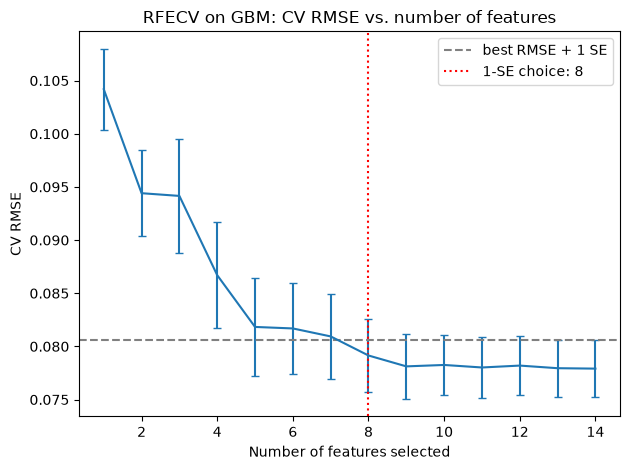

In [15]:
sel = GBModel.named_steps["featureSelec"]
n_folds = tune_cv.get_n_splits()

cv_results = pd.DataFrame({
    "n_features": sel.cv_results_["n_features"],
    "rmse": -sel.cv_results_["mean_test_score"],
    "se": sel.cv_results_["std_test_score"] / np.sqrt(n_folds),
})

best = cv_results["rmse"].min()
threshold = best + cv_results.loc[cv_results["rmse"].idxmin(), "se"]
n_one_se = cv_results.loc[cv_results["rmse"] <= threshold, "n_features"].min()

figRfecv = plt.figure()
plt.errorbar(cv_results["n_features"], cv_results["rmse"], yerr=cv_results["se"], capsize=3)
plt.axhline(threshold, ls="--", color="gray", label="best RMSE + 1 SE")
plt.axvline(n_one_se, ls=":", color="red", label=f"1-SE choice: {n_one_se}")
plt.xlabel("Number of features selected")
plt.ylabel("CV RMSE")
plt.title("RFECV on GBM: CV RMSE vs. number of features")
plt.legend()
plt.tight_layout()
plt.show()

About 8 of the 14 encoded features are enough. The four division dummies and both missing-value flags, all binary add nothing measurable. RFE ranks by impurity importance, which favors continuous features with many split points over dummies and indicators, so the six may be undervalued rather than useless. The ablation below rechecks this on the original columns, where dropping division removes all four dummies at once.

Ranking

In [16]:
names = GBModel.named_steps["prep"].get_feature_names_out()
Xt = GBModel.named_steps["prep"].transform(X_train)
rfeFull = RFE(GradientBoostingRegressor(random_state=42, **gbm_params), n_features_to_select=1).fit(Xt, y_train)
order = pd.Series(rfeFull.ranking_, index=names).sort_values()
print(order)

num__testScore                    1
num__ugTotal                      2
num__upPell                       3
num__expPerStudent                4
num__admRate                      5
num__adminShare                   6
num__instrShare                   7
num__spendRate                    8
ind__admRateMissing               9
cat__division_D-II               10
cat__division_D-III              11
cat__division_D-I no football    12
ind__testScoreMissing            13
cat__division_D-I FCS            14
dtype: int64


Ablation

Drop-column ablation. Starting from the full 14-column tuned GBM, refit with each raw column removed and measure the change in cohort-weighted CV RMSE. The CV folds are fixed, so differences are computed fold by fold (paired), which cancels out the "this fold was hard" noise; a feature matters if its mean increase is clearly larger than the paired SE. Dropping a raw column removes all of its encoded columns at once, which sidesteps the impurity-importance bias against dummies.

Two extra rows drop groups together: the four spending variables, and admRate with its missing flag. This catches variables that are individually redundant but jointly necessary.

In [17]:
results2 = {}

def makePipeline(dropCols):

    num2 = [c for c in num if c not in dropCols]
    ind2 = [c for c in ind if c not in dropCols]
    cat2 = [c for c in cat if c not in dropCols]

    preprocess2 = ColumnTransformer([
        ("num2", Pipeline([("impute", SimpleImputer(strategy="median")),
                           ("scale",  StandardScaler().set_fit_request(sample_weight=False))]), num2),
        ("ind2", "passthrough", ind2),
        ("cat2", OneHotEncoder(drop="first", handle_unknown="ignore"), cat2),
        ])

    GBModel3 = Pipeline([("prep", preprocess2), ("model", GradientBoostingRegressor(random_state=42,
                                                                                     **gbm_params).set_fit_request(sample_weight=True))])
    return GBModel3

def buildGBMDropCols(dropCols):
    
    GBModel3 = makePipeline(dropCols)
    X_model = X_train.drop(columns=dropCols)

    res = cross_validate(GBModel3, X_model, y_train, cv=cv,
                        scoring=scoring["rmse"],
                        params={"sample_weight": w_train}, n_jobs=-1)
    return(-res["test_score"])

results2["Base"] = {"rmse": buildGBMDropCols([])}

for col in X_train.columns:     # Drop columns 1 by 1
    results2[col] = {"rmse": buildGBMDropCols([col])}

results2["spending"]    = {"rmse": buildGBMDropCols(["spendRate", "expPerStudent", "instrShare", "adminShare"])}
results2["admRatePair"] = {"rmse": buildGBMDropCols(["admRate", "admRateMissing"])}

In [18]:
rmseScores = {col: results2[col]["rmse"] for col in results2.keys()}
rmseScores = pd.DataFrame(rmseScores).transpose()
baseScores = rmseScores.loc["Base"]
rmseSubs = rmseScores - baseScores

deltaTable = pd.DataFrame()
deltaTable["Mean"]= rmseSubs.drop(index=["Base"]).mean(axis=1)
deltaTable["SE"] = rmseSubs.drop(index=["Base"]).std(axis=1, ddof=1) / np.sqrt(cv.n_repeats)
deltaTable["Mean/SE"] = deltaTable["Mean"] / deltaTable["SE"]
deltaTable["pct"] = 100 * deltaTable["Mean"] / rmseScores.loc["Base"].mean()

deltaTable = deltaTable.sort_values("Mean")
print(deltaTable)

                      Mean        SE   Mean/SE        pct
spendRate        -0.000587  0.000471 -1.244404  -0.898820
instrShare        0.000066  0.000386  0.170463   0.100757
division          0.000180  0.000251  0.715222   0.275532
admRateMissing    0.000244  0.000297  0.820205   0.373696
testScoreMissing  0.000317  0.000166  1.913643   0.485455
adminShare        0.000450  0.000729  0.616940   0.689284
expPerStudent     0.002007  0.001540  1.303251   3.075229
testScore         0.002186  0.001650  1.325087   3.349883
spending          0.002762  0.001845  1.496918   4.232210
ugTotal           0.002805  0.001531  1.832088   4.297997
admRate           0.004217  0.002169  1.943788   6.461201
admRatePair       0.004558  0.002075  2.196975   6.983918
upPell            0.007823  0.001431  5.465534  11.986876


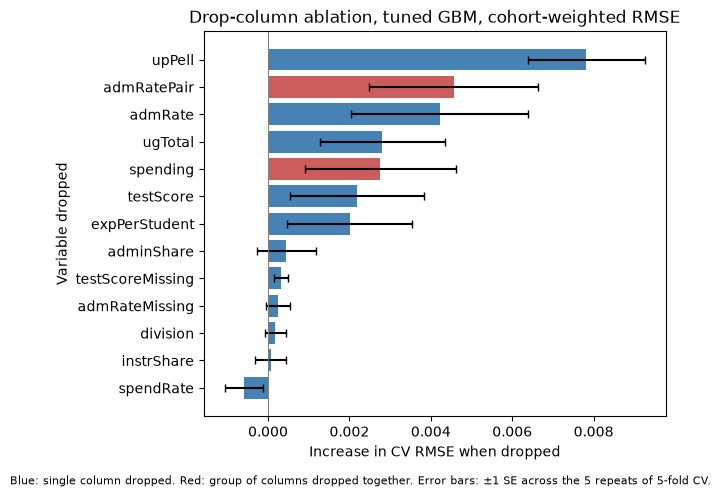

In [19]:
color = ["steelblue"  if c not in ["spending", "admRatePair"] else "indianred" for c in deltaTable.index]

figAblation = plt.figure()
plt.barh(deltaTable.index, deltaTable["Mean"], xerr=deltaTable["SE"],
         capsize=3, color = color)
plt.xlabel("Increase in CV RMSE when dropped")
plt.ylabel("Variable dropped")
plt.title("Drop-column ablation, tuned GBM, cohort-weighted RMSE")
plt.axvline(0, color="gray", lw=0.8)
plt.figtext(0.5, -0.02, "Blue: single column dropped. Red: group of columns dropped together. Error bars: ±1 SE across the 5 repeats of 5-fold CV.",
            ha="center", fontsize=8)
plt.tight_layout()
plt.show()

Division adds nothing once schools are cohort-weighted (0.0002, 0.7 SE). The unweighted run had it at 2% of RMSE; large cohorts are almost all D-I, so weighting leaves little division variance to explain. RFE had already dropped the dummies, but for the wrong reason: it dropped only binary columns, which is the impurity bias, not a finding. The ablation shows division and admRateMissing would have gone anyway; testScoreMissing (1.9 SE) was the one casualty of the bias.

RFE and ablation disagree at the top. Impurity ranks testScore first, ugTotal second, upPell third. Ablation has upPell alone at 12% of RMSE (5.5 SE) and testScore and ugTotal mid-pack at 3–4% (1.3–1.8 SE). Impurity counts how often a feature gets split on, and continuous variables get split on a lot; ablation counts what's lost without it, and testScore and ugTotal are substitutable while Pell share isn't. Admission rate is second (6%, ~2 SE); its missing flag adds nothing on top, so the pair is really just admRate.

Spending is weak however it's sliced. The group costs 4% (1.5 SE), nearly all from expPerStudent; the three share variables contribute nothing individually, and the model predicts slightly better without spendRate (−0.0006, −1.2 SE). RFE kept it at rank 8, the last one inside the 1-SE set. Athletic spending share has no predictive value for graduation rate once selectivity and resources are in the model.

Held-out test. Refit the retained linear model and the tuned GBM on the full training set, same features as the CV comparison, and score each once on the 20% test split with cohort-weighted RMSE and R². The linear model is the one being claimed; the GBM row is there to show the test set agrees with the CV ranking.

In [20]:
testResults = {}
for name in ["linear", "gbm"]:
    m = pipes[name].fit(X_train, y_train, sample_weight=w_train)
    p = m.predict(X_test)
    testResults[name] = {
        "rmse": root_mean_squared_error(y_test, p, sample_weight=w_test),
        "r2":   r2_score(y_test, p, sample_weight=w_test),
    }
print(pd.DataFrame(testResults).T.round(3))

         rmse     r2
linear  0.060  0.853
gbm     0.065  0.828


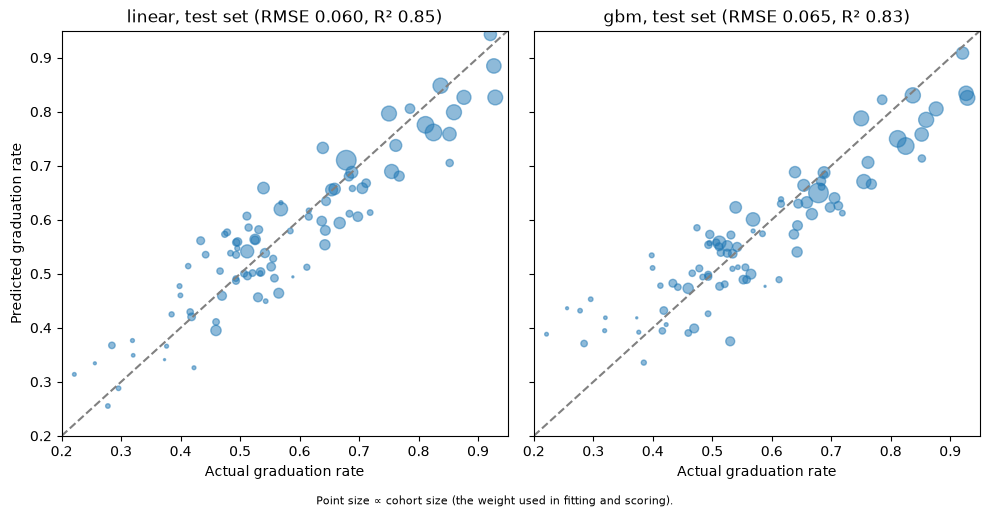

In [21]:
preds = {name: pipes[name].predict(X_test) for name in ["linear", "gbm"]}

figPred, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
lims = [0.2, 0.95]
for ax, name in zip(axes, ["linear", "gbm"]):
    ax.scatter(y_test, preds[name], s=w_test / w_test.max() * 200, alpha=0.5)
    ax.plot(lims, lims, "--", color="gray")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Actual graduation rate")
    ax.set_title(f"{name}, test set (RMSE {testResults[name]['rmse']:.3f}, "
                 f"R² {testResults[name]['r2']:.2f})")
axes[0].set_ylabel("Predicted graduation rate")
plt.figtext(0.5, -0.02, "Point size ∝ cohort size (the weight used in fitting and scoring).",
            ha="center", fontsize=8)
plt.tight_layout()
plt.show()

Test RMSE 0.060 (R² 0.85) for the linear model and 0.065 (R² 0.83) for the tuned GBM, both in line with their CV estimates; the linear model's slight improvement over CV is within what one 89-school split can do. The ranking holds out of sample. The GBM compresses the extremes by 5–10 points (predicts too high for the worst schools, too low for the best), which is normal for tree ensembles.

Partial Dependence Plots

Partial dependence from the tuned GBM: average predicted grad rate as one feature is moved across its range while every other feature stays at its real value. Gives direction and shape, which the linear coefficient can't. The linear model's dependence is overlaid for comparison — where the two agree over the middle of the data, the coefficient is the right summary; where the GBM bends, the linear form is missing something. Tick marks at the bottom are data deciles; the curve isn't trustworthy where they're sparse, and the GBM flattens at both edges regardless (the same tail compression seen on the test set), so judge shape from the central 80%. ugTotal and expPerStudent are on log scale.

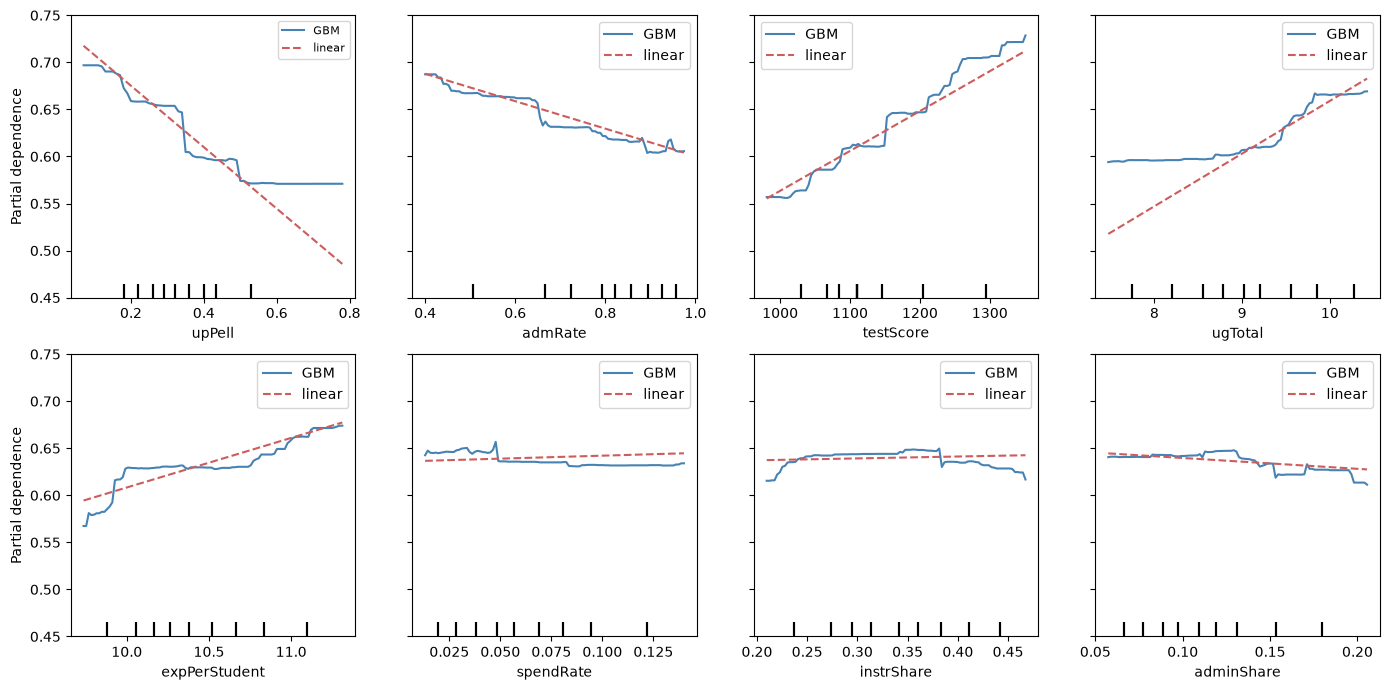

In [22]:
X_pd = X_train.fillna(X_train.median(numeric_only=True))
numFeats = ["upPell", "admRate", "testScore", "ugTotal", "expPerStudent", "spendRate", "instrShare", "adminShare"]

figPdp, ax = plt.subplots(figsize=(14, 7))
disp = PartialDependenceDisplay.from_estimator(
    pipes["gbm"], X_pd, features=numFeats, kind="average", n_cols=4,
    sample_weight=w_train, ax=ax, line_kw={"color": "steelblue", "label": "GBM"})
PartialDependenceDisplay.from_estimator(
    pipes["linear"], X_pd, features=numFeats, kind="average",
    sample_weight=w_train, ax=disp.axes_, line_kw={"color": "indianred", "ls": "--", "label": "linear"})

for a in figPdp.axes: a.set_ylim(0.45, 0.75)
disp.axes_[0, 0].legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()


Over the range where the data is, the GBM's partial dependence follows the linear model's for Pell share, admission rate, test score, per-student spending, and all three spending shares. Pell share is the steepest by far; the GBM's flattening above 0.5 is outside the data deciles and is tail compression, not a ceiling. spendRate is flat under both models, consistent with the ablation and the WLS.

The one disagreement is enrollment. The GBM is flat below roughly 3,000 undergraduates and rises above; the linear model draws one slope through both. Checked below against the WLS residuals and a hinge term.

Athletic, administrative, and instructional spending shares are flat under both models. Per-student spending is not: about 3.5 points per doubling in the WLS, clearly significant, though the ablation rates it weakly because it shares information with test scores and enrollment. Resources matter; how they're split between athletics, instruction, and administration does not.

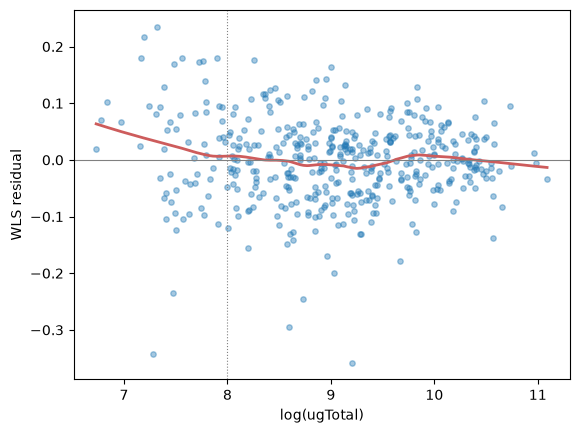

In [23]:
resid = m_final.resid
logUg = np.log(featuresFilled.loc[resid.index, "ugTotal"])
sm_ = lowess(resid, logUg, frac=0.3)

figResid, ax = plt.subplots()
ax.scatter(logUg, resid, alpha=0.4, s=15)
ax.plot(sm_[:, 0], sm_[:, 1], color="indianred", lw=2)
ax.axhline(0, color="gray", lw=0.8)
ax.axvline(8, color="gray", ls=":", lw=0.8)
ax.set_xlabel("log(ugTotal)"); ax.set_ylabel("WLS residual")
plt.show()

In [24]:
for knot in [8, 9]:
    m_hinge = smf.wls(f"gradRate ~ spendRate + np.log(expPerStudent) + instrShare + adminShare + upPell + testScore + testScoreMissing + np.log(ugTotal) + I(np.maximum(np.log(ugTotal) - {knot}, 0)) + admRate + admRateMissing + C(division)",
                      data=featuresFilled, weights=featuresFilled["cohortSize"]).fit(cov_type="HC3")
    h = [t for t in m_hinge.params.index if "maximum" in t][0]
    print(f"knot {knot}: hinge = {m_hinge.params[h]:.4f}, HC3 p = {m_hinge.pvalues[h]:.3f}, "
          f"F p = {anova_lm(m_final, m_hinge)['Pr(>F)'][1]:.3f}")

knot 8: hinge = 0.0685, HC3 p = 0.060, F p = 0.113
knot 9: hinge = 0.0322, HC3 p = 0.087, F p = 0.050


Residuals against log enrollment bend only in the bottom decile. Most of the GBM's pattern was the omitted per-student spending term; with it in, what's left is faint. Hinges at 3,000 and 8,000 undergraduates were tested and neither improves fit significantly (HC3 p = 0.06 and 0.09; F p = 0.11 and 0.05). The linear form is retained. The small-school departure is real but carries almost no cohort weight.

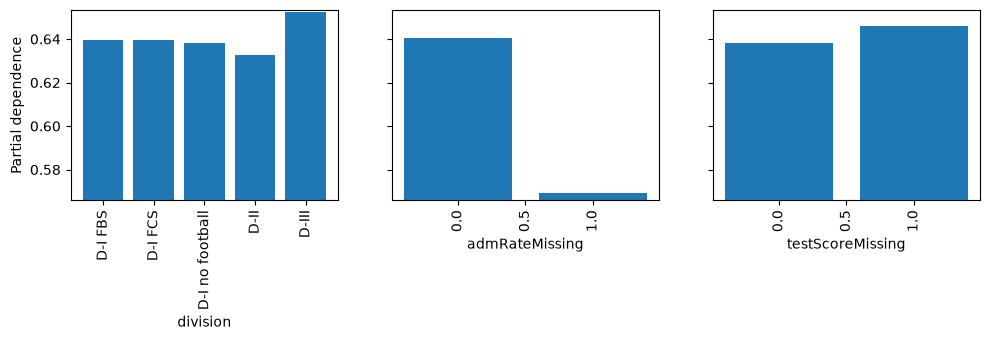

In [25]:
figPdpCat, ax = plt.subplots(figsize=(10, 3.5))
PartialDependenceDisplay.from_estimator(
    pipes["gbm"], X_pd, features=["division", "admRateMissing", "testScoreMissing"],
    categorical_features=["division", "admRateMissing", "testScoreMissing"],
    kind="average", n_cols=3, sample_weight=w_train, ax=ax)
plt.tight_layout(); plt.show()

The GBM agrees with the WLS on direction for every categorical, D-III highest, missing admission rate lowest, missing test score slightly higher, but shrinks each effect to a quarter to a half of the WLS estimate. Shallow boosted trees underuse binary splits when continuous predictors are available, which is also why the ablation found division dispensable. The WLS coefficients are the better estimates here.

Bigger schools, higher test scores, and higher per-student spending are associated with higher graduation rates. Doubling per-student spending is worth about 3.5 points; doubling enrollment about 4.

Higher admission rates, a missing admission rate, and a higher Pell share are associated with lower graduation rates. Pell share is the largest effect in the model: going from 20% to 50% Pell costs about 11 points, holding everything else fixed. Schools that don't report test scores graduate about 4 points more than their other characteristics predict, probably test-optional selective schools.

D-III sits about 7 points above FBS. The other three divisions are 2–3 points above and marginal, so football status does nothing once composition is controlled.

None of the spending shares matter. Athletic, instructional, and administrative share are all flat once total per-student resources are in the model.

Why does raw division matter so much (47% D-II vs 67% FBS) when the adjusted effect is ~3 points in the other direction (D-II is 20 points below FBS raw, 3 above adjusted)? Because divisions enroll different students.
 
FBS vs FCS is the clean comparison: nearly identical athletic spending shares (7.2% vs 7.7%), 14 point graduation gap, 120 point test score gap, and FBS schools are nearly three times the size with a lower Pell share. If spending share drove graduation these two rows would look alike.

In [26]:
g = features.groupby("division")
divTable = g[["testScore", "upPell", "ugTotal", "admRate", "spendRate", "gradRate", "expPerStudent"]].median().round(3)
divTable.insert(0, "n", g.size())
divTable

,n,testScore,upPell,ugTotal,admRate,spendRate,gradRate,expPerStudent
division,,,,,,,,
D-I FBS,108,1198.737,0.26,22673.5,0.770,0.072,0.672,49212.522
D-I FCS,75,1080.000,0.33,8215.0,0.859,0.077,0.531,32650.032
D-I no football,46,1114.309,0.33,11962.0,0.814,0.043,0.555,35167.843
D-II,143,1075.477,0.37,5265.0,0.871,0.057,0.473,25447.959
D-III,73,1173.455,0.34,4859.0,0.807,0.022,0.584,33765.850


# Conclusion
 
Athletic spending share has no detectable association with graduation rate once total resources are in the model. It looks negative and significant with partial controls, and that's a denominator artifact: spendRate is athletic spending over total expenditure, so without per-student spending in the model a high share just means a small budget. Add per-student spending and the coefficient is +0.11 (CI −0.11 to +0.33), about half a graduation point per 5 points of share, with the interval spanning ±1 point. The GBM finds no predictive value in athletic share and its PDP is flat.

Graduation rates are driven by Pell share, selectivity, test scores, enrollment, and per-student spending. Division differences are almost entirely composition: FBS and FCS have the same athletic share and a 14 point graduation gap that tracks a 120 point test score gap. Adjusted, D-III sits ~7 points above FBS and the rest are within 3.

The negative associations that show up between athletic spending and graduation are, in this data, what omitted variable bias looks like.

# Outputs

In [27]:
# Tables
cv_table.to_csv("../Output/Tables/07_cv_model_comparison.csv", index_label="model")

order.rename("rank").rename_axis("feature").to_csv("../Output/Tables/08_rfe_feature_ranking.csv")

deltaTable.round(4).to_csv("../Output/Tables/09_ablation_rmse_delta.csv", index_label="dropped")

(pd.DataFrame(testResults).T
   .assign(nFeatures=X_train.shape[1], nTest=len(y_test))
   .round(4)
   .to_csv("../Output/Tables/10_test_set_metrics.csv", index_label="model"))

divTable.to_csv("../Output/Tables/11_division_composition.csv", index_label="division")

m_final.summary2().tables[1].round(4).to_csv("../Output/Tables/12_wls_full_model.csv", index_label="term")

# Plots
figRfecv.savefig("../Output/Plots/07_rfecv_curve.png", dpi=300, bbox_inches="tight")
figAblation.savefig("../Output/Plots/08_ablation_importance.png", dpi=300, bbox_inches="tight")
figPred.savefig("../Output/Plots/09_pred_vs_actual.png", dpi=300, bbox_inches="tight")
figPdp.savefig("../Output/Plots/10_pdp_numeric.png", dpi=300, bbox_inches="tight")
figPdpCat.savefig("../Output/Plots/11_pdp_categorical.png", dpi=300, bbox_inches="tight")
figResid.savefig("../Output/Plots/12_wls_resid_vs_enrollment.png", dpi=300, bbox_inches="tight")
